# Checking time of metrics

In [7]:
# Импорт библиотек
import os, sys
import argparse
import pandas as pd
from tqdm.auto import tqdm
from evaluate import load
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import re
from pymorphy2 import MorphAnalyzer

In [2]:
bertscore = load("bertscore")
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\')
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\prose-to-poetry')
sys.path.append('c:\\Program Files (x86)\\eSpeak\\command_line')

In [3]:
%cd c:\HSE\project_poetry_2\ProjectPoetryRL

c:\HSE\project_poetry_2\ProjectPoetryRL


c:\HSE\project_poetry_2\ProjectPoetryRL\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
from metrics import check_meter, check_meter_fast, \
        check_rhyme_scheme, get_rhyme_score, format_score,  embedding_sim_score, encode_sent
from util import filter_lines as filter_lines_
import language_tool_python 

tool = language_tool_python.LanguageTool('ru-RU')

In [ ]:
def filter_lines(text):
    lines = []
    for line in text.split('\n'):
        line = line.strip()
        for ch in line:
            if ch.isalpha():
                lines.append(line)
                break
    return lines
    
def check_len(lines):
    if len(lines) == 4 or len(lines) == 8:
        return 1.
    return 0.

# ===== FORMAT =====
def format_score_fn(df):
    scores = []
    for output in df["output"]:
        lines = output.split("\n")
        f_lines = filter_lines_(lines)
        scores.append(format_score(lines, f_lines))
    return np.array(scores)


# ===== RHYME OLD =====
def rhyme_score_fn(df):
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        scores.append(check_rhyme_scheme(lines, row["rhyme_scheme"]))
    return np.array(scores)


# ===== RHYME NEW =====
def rhyme_score_new_fn(df):
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        scores.append(get_rhyme_score(lines, row["rhyme_scheme"]))
    return np.array(scores)


# ===== METER =====
def meter_score_fn(df):
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        scores.append(check_meter(lines, row["meter"]))
    return np.array(scores)


# ===== METER FAST =====
def meter_score_fast_fn(df):
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        scores.append(check_meter_fast(lines, row["meter"], row["rhyme_scheme"]))
    return np.array(scores)


# ===== BERTScore =====
def bertscore_fn(df):
    outputs = df["output"].tolist()
    references = df["text"].tolist()

    result = bertscore.compute(
        predictions=outputs,
        references=references,
        lang="ru"
    )
    return np.array(result["f1"])


# ===== SEMANTIC EMBEDDINGS =====
def semantic_embedding_fn(df):
    outputs = df["output"].tolist()
    references = df["text"].tolist()

    emb_prose = encode_sent(references)
    emb_poem = encode_sent(outputs)

    cos_sim = F.cosine_similarity(emb_prose, emb_poem, dim=1)
    return cos_sim.cpu().numpy()

morph = MorphAnalyzer()

def unknown_word_ratio_fn(df):
    scores = []

    for text in df["output"]:
        words = re.findall(r"[а-яёА-ЯЁ]+", text)

        if not words:
            scores.append(0.0)
            continue

        unknown = 0

        for w in words:
            parses = morph.parse(w)
            best = parses[0]
            print(w, parses)

            if 'UNKN' in best.tag or best.score < 0.2:
                print("!")
                unknown += 1

        scores.append(unknown / len(words))

    return np.array(scores)



def grammar_errors_batch_fn(df):
    texts = df["output"].tolist()
    matches = tool.check(texts)  # batch

    scores = []
    for m_list, text in zip(matches, texts):
        n_errors = len(m_list)
        length = max(len(text.split()), 1)
        scores.append(n_errors / length)

    return np.array(scores)

In [41]:
text = 'Михаил Лермонтов анна Антоновна Дистлер Челяябинск Старик испуган, сын молчит, крадти нжн В глазах сына смысл ясит.   Старец сыну взглядом притягивает,   Взмахнув старческими руками.'
#tool.check(text)

In [42]:
unknown_word_ratio_fn(pd.DataFrame({'output': [text]}))

Михаил [Parse(word='михаил', tag=OpencorporaTag('NOUN,anim,masc,Name sing,nomn'), normal_form='михаил', score=1.0, methods_stack=((DictionaryAnalyzer(), 'михаил', 27, 0),))]
Лермонтов [Parse(word='лермонтов', tag=OpencorporaTag('NOUN,anim,masc,Sgtm,Surn sing,nomn'), normal_form='лермонтов', score=1.0, methods_stack=((DictionaryAnalyzer(), 'лермонтов', 37, 0),))]
анна [Parse(word='анна', tag=OpencorporaTag('NOUN,anim,femn,Name sing,nomn'), normal_form='анна', score=1.0, methods_stack=((DictionaryAnalyzer(), 'анна', 69, 0),))]
Антоновна [Parse(word='антоновна', tag=OpencorporaTag('NOUN,anim,femn,Patr sing,nomn'), normal_form='антонович', score=1.0, methods_stack=((DictionaryAnalyzer(), 'антоновна', 26, 12),))]
Дистлер [Parse(word='дистлер', tag=OpencorporaTag('NOUN,anim,femn,Name plur,gent'), normal_form='дистлера', score=0.2542372881355931, methods_stack=((DictionaryAnalyzer(), 'лер', 237, 8), (UnknownPrefixAnalyzer(score_multiplier=0.5), 'т'), (KnownPrefixAnalyzer(known_prefixes=<...>,

array([0.08333333])

In [15]:
def eval_metrics(df, metric_fns: dict):
    """
    metric_fns: dict[str, callable(df) -> np.array]
    """

    metrics = {}
    times = {}

    for name, fn in metric_fns.items():
        start = time.perf_counter()
        scores = fn(df)
        times[name] = time.perf_counter() - start

        metrics[name] = np.array(scores)

    # ===== статистика =====
    stats = []
    for name, scores in metrics.items():
        stats.append({
            "metric": name,
            "mean": scores.mean(),
            "std": scores.std(),
            "time_sec": times[name] / len(df)
        })

    stats_df = pd.DataFrame(stats).set_index("metric")

    print("\nMetric statistics:")
    print(stats_df)

    return stats_df, metrics


def viz_metrics(metrics):
    # -------- распределения --------
    plt.figure(figsize=(15, 10))

    for i, (name, scores) in enumerate(metrics.items(), 1):
        plt.subplot(2, 4, i)
        plt.hist(scores, bins=30)
        plt.title(name)

    plt.tight_layout()
    plt.show()

    df_metrics = pd.DataFrame(metrics)
    corr = df_metrics.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Корреляция между метриками")
    plt.show()

In [16]:
test_dataset = 'dataset/prosa_test_text_prev.csv'
input_file = 'output_old/qwen.csv'

inputs = pd.read_csv(test_dataset)
outputs = pd.read_csv(input_file)
df = pd.concat([inputs, outputs], axis=1).rename({'qwen': 'output'}, axis=1)

In [26]:
unknown_word_ratio_fn
metric_fns = {
    "format": format_score_fn,
    "unknown": unknown_word_ratio_fn,
    #"grammar": grammar_errors_batch_fn,
}

stats_df, metrics = eval_metrics(df, metric_fns)


Metric statistics:
             mean       std  time_sec
metric                               
format   0.956040  0.140435  0.000012
unknown  0.014913  0.031152  0.003843


In [ ]:
metric_fns = {
    "format": format_score_fn,
    "rhyme_old": rhyme_score_fn,
    "rhyme_new": rhyme_score_new_fn,
    "meter": meter_score_fn,
    "meter_fast": meter_score_fast_fn,
    "bertscore": bertscore_fn,
    "semantic": semantic_embedding_fn,
}

stats_df, metrics = eval_metrics(df, metric_fns)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:05<00:00, 171.50it/s]



Metric statistics:
                         mean       std  time_sec
metric                                           
BERTscore            0.773638  0.073938  0.153218
semantic_embeddings  0.839702  0.100604  0.103982
len_score            0.963753  0.135939  0.000023
rhyme_score          0.043525  0.147585  0.242566
rhyme_score_new      0.053884  0.144477  0.251015
meter_score          0.408783  0.109070  0.007873
meter_score_fast     0.710676  0.068141  0.005835


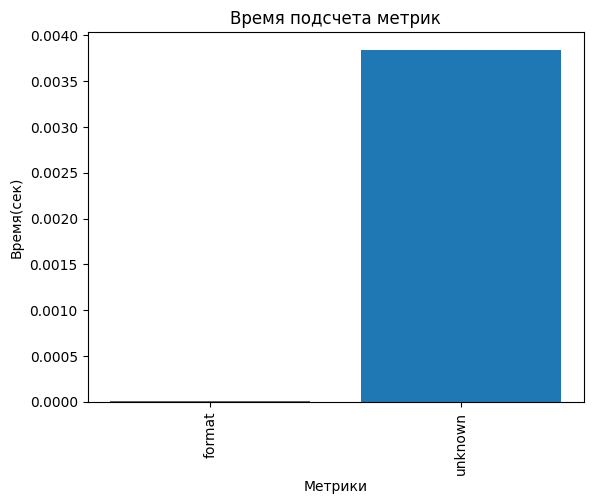

In [27]:
stats_df_ = stats_df.copy()#.drop('entailment')
plt.bar(stats_df_.index, stats_df_['time_sec'])

plt.xlabel("Метрики")
plt.ylabel("Время(сек)")
plt.title("Время подсчета метрик")
plt.xticks(rotation=90)
plt.show()

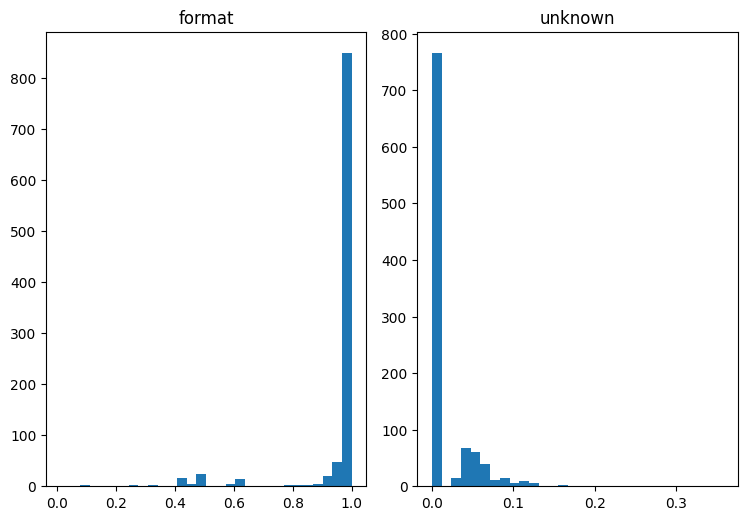

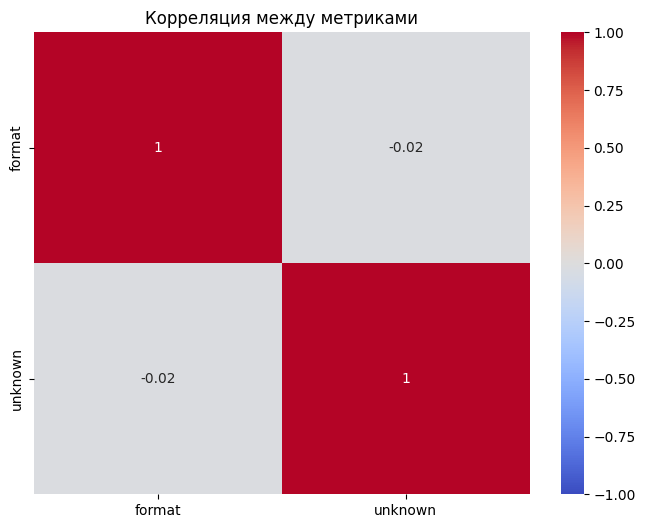

In [28]:
metrics_ = metrics.copy()
viz_metrics(metrics_)

In [21]:
cosine = np.array(metrics["semantic_embeddings"])
bert = np.array(metrics["BERTscore"])

# разница
diff = cosine - bert

# индексы
top_cosine_idx = np.argsort(-diff)[:10]   # cosine сильно больше
top_bert_idx = np.argsort(diff)[:10]      # bertscore сильно больше

def print_examples(indices, title):
    print(f"\n{'='*20} {title} {'='*20}")
    for i in indices:
        print(f"\nIndex: {i}")
        print(f"Cosine: {cosine[i]:.4f} | BERTScore: {bert[i]:.4f} | Diff: {diff[i]:.4f}")
        print(f"\nSRC:\n{df['text'][i]}")
        print(f"\nGEN:\n{df['output'][i]}")
        print("-"*50)

# вывод
print_examples(top_cosine_idx, "Cosine >> BERTScore")
print_examples(top_bert_idx, "BERTScore >> Cosine")


==================== Cosine >> BERTScore ====================

Index: 951
Cosine: 0.8756 | BERTScore: 0.6431 | Diff: 0.2325

SRC:
Разоблаченные владыки мира не могут противопоставить наполеоновскому идеалу славы и величия, не имеющего смысла, никакого разумного идеала.


GEN:
Не владыки мирозданья силы,
Наполеона идеал не удержит,
Безумный стремленье славы путь
В безбрежье мглы непостижим.
--------------------------------------------------

Index: 397
Cosine: 0.9359 | BERTScore: 0.7053 | Diff: 0.2306

SRC:
Он молился, просил бога помочь ему, вселиться в него и очистить его, а между тем то, о чем он просил, уже совершилось.


GEN:
Молился он, бога молил,
Чтоб в душу его войти,
И очистить грехи свои,
А то, о чем молил, уже было.

Он молился, чтоб в себя войти,
Бога просил помочь,
Чтоб очистить сердце свое,
А то, о чем молил, уже было.
--------------------------------------------------

Index: 890
Cosine: 0.9116 | BERTScore: 0.6843 | Diff: 0.2273

SRC:
Она разливала чай – слушая неистощи

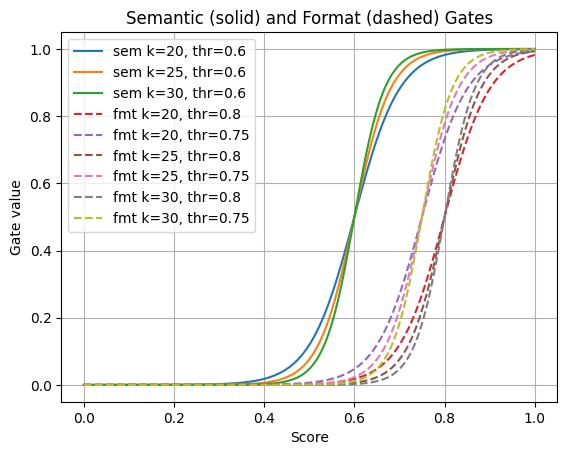

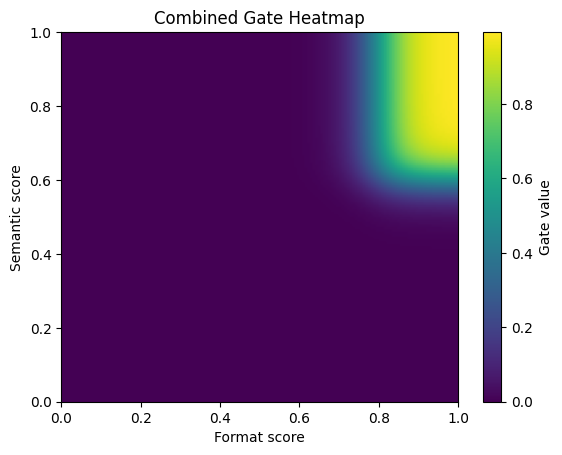

Gate(1,1) = 0.993301
⚠️ Gate далеко от 1 — возможно слишком мягкие параметры


In [17]:
import torch
import matplotlib.pyplot as plt

def compute_gate(sem_scores, format_scores,
                 k_sem=8.0, k_format=5.0,
                 sem_thr=0.7, format_thr=0.9):
    gate_sem = torch.sigmoid(k_sem * (sem_scores - sem_thr))
    gate_fmt = torch.sigmoid(k_format * (format_scores - format_thr))
    return gate_sem * gate_fmt


def check_gate_at_one(k_sem=8.0, k_format=5.0,
                      sem_thr=0.7, format_thr=0.9,
                      tol=1e-3):
    sem = torch.tensor([1.0])
    fmt = torch.tensor([1.0])

    gate = compute_gate(sem, fmt, k_sem, k_format, sem_thr, format_thr)

    print(f"Gate(1,1) = {gate.item():.6f}")

    if abs(gate.item() - 1.0) < tol:
        print("✅ OK: gate ≈ 1")
    else:
        print("⚠️ Gate далеко от 1 — возможно слишком мягкие параметры")


def plot_gates(
    k_sem_list=(8.0,),
    k_format_list=(5.0,),
    sem_thr_list=(0.7,),
    format_thr_list=(0.9,),
    num_points=200
):
    """
    Рисует отдельные сигмоиды для semantic и format
    """
    scores = torch.linspace(0, 1, num_points)

    plt.figure()

    # Semantic (сплошные линии)
    for k_sem in k_sem_list:
        for sem_thr in sem_thr_list:
            gate_sem = torch.sigmoid(k_sem * (scores - sem_thr))
            plt.plot(
                scores.numpy(),
                gate_sem.numpy(),
                label=f"sem k={k_sem}, thr={sem_thr}"
            )

    # Format (пунктир)
    for k_fmt in k_format_list:
        for fmt_thr in format_thr_list:
            gate_fmt = torch.sigmoid(k_fmt * (scores - fmt_thr))
            plt.plot(
                scores.numpy(),
                gate_fmt.numpy(),
                linestyle="--",
                label=f"fmt k={k_fmt}, thr={fmt_thr}"
            )

    plt.xlabel("Score")
    plt.ylabel("Gate value")
    plt.title("Semantic (solid) and Format (dashed) Gates")
    plt.legend()
    plt.grid()
    plt.show()


def plot_combined_gate(
    k_sem=8.0,
    k_format=5.0,
    sem_thr=0.7,
    format_thr=0.9,
    num_points=150
):
    """
    Heatmap для итогового gate = gate_sem * gate_fmt
    """
    sem = torch.linspace(0, 1, num_points)
    fmt = torch.linspace(0, 1, num_points)

    sem_grid, fmt_grid = torch.meshgrid(sem, fmt, indexing="ij")

    gate_sem = torch.sigmoid(k_sem * (sem_grid - sem_thr))
    gate_fmt = torch.sigmoid(k_format * (fmt_grid - format_thr))
    gates = gate_sem * gate_fmt

    plt.figure()
    plt.imshow(
        gates.numpy(),
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto"
    )
    plt.xlabel("Format score")
    plt.ylabel("Semantic score")
    plt.title("Combined Gate Heatmap")
    plt.colorbar(label="Gate value")
    plt.show()


# ===== Примеры =====

# 1. Посмотреть разные параметры
plot_gates(
    k_sem_list=[20, 25, 30],
    k_format_list=[ 20, 25, 30],
    sem_thr_list=[ 0.6],
    format_thr_list=[ 0.8, 0.75]
)

# 2. Heatmap текущего гейта
plot_combined_gate(k_sem=30.0,
    k_format=25.0,
    sem_thr=0.6,
    format_thr=0.8,)

check_gate_at_one(k_sem=30.0,
    k_format=25.0,
    sem_thr=0.6,
    format_thr=0.8,)